# 🔥 Введение в PyTorch — Практика для начинающих

В этом ноутбуке мы изучим основы PyTorch шаг за шагом.
После каждого нового понятия вас ждёт **небольшое задание** с автоматической проверкой.

> **Как работать:** читайте объяснение → запускайте примеры → выполняйте задания ✅


---
## 📦 Часть 1. Установка и импорт PyTorch

Запустите ячейку ниже, чтобы убедиться, что PyTorch установлен.


In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

print("✅ PyTorch версия:", torch.__version__)
print("💻 Устройство:", "GPU (CUDA)" if torch.cuda.is_available() else "CPU")


✅ PyTorch версия: 2.11.0+cpu
💻 Устройство: CPU


---
## 🧱 Часть 2. Тензоры — основа PyTorch

**Тензор** — это многомерный массив, как `numpy.array`, но с поддержкой GPU и автодифференцирования.

| Размерность | Название | Пример |
|:-----------:|:--------:|:------:|
| 0D | Скаляр | `42` |
| 1D | Вектор | `[1, 2, 3]` |
| 2D | Матрица | `[[1,2],[3,4]]` |
| 3D+ | Тензор | батч изображений |


In [2]:
# Создаём тензоры разных размерностей
scalar = torch.tensor(42.0)
vector = torch.tensor([1.0, 2.0, 3.0])
matrix = torch.tensor([[1.0, 2.0], [3.0, 4.0]])

print(f"Скаляр:  {scalar}  | размерность: {scalar.ndim}D | форма: {scalar.shape}")
print(f"Вектор:  {vector}  | размерность: {vector.ndim}D | форма: {vector.shape}")
print(f"Матрица:\n{matrix}  | размерность: {matrix.ndim}D | форма: {matrix.shape}")


Скаляр:  42.0  | размерность: 0D | форма: torch.Size([])
Вектор:  tensor([1., 2., 3.])  | размерность: 1D | форма: torch.Size([3])
Матрица:
tensor([[1., 2.],
        [3., 4.]])  | размерность: 2D | форма: torch.Size([2, 2])


### 🔨 Задание 1. Создайте свой тензор

Создайте матрицу `my_matrix` размером **3×3** из чисел от 1 до 9 (целые числа типа `float`).
Затем выведите её **форму** и **размерность**.

**Ожидаемый результат:**
```
Форма: torch.Size([3, 3])
Размерность: 2D
```


In [4]:
# TODO: создайте матрицу 3×3 из чисел [1..9] типа float
# Подсказка: torch.tensor([[...], [...], [...]])

my_matrix = None  # ← замените None на ваш код

# ── Проверка (не изменяйте) ──────────────────
assert my_matrix is not None, "❌ Создайте тензор my_matrix"
assert my_matrix.shape == torch.Size([3, 3]), f"❌ Форма должна быть [3,3], а не {my_matrix.shape}"
assert my_matrix.dtype in (torch.float32, torch.float64), f"❌ Тип должен быть float, а не {my_matrix.dtype}"
print(f"✅ Форма: {my_matrix.shape}")
print(f"✅ Размерность: {my_matrix.ndim}D")


AssertionError: ❌ Создайте тензор my_matrix

---
## 🏭 Часть 3. Способы создания тензоров

PyTorch предлагает много удобных функций для создания тензоров.


In [5]:
# Нули, единицы, случайные числа
zeros  = torch.zeros(2, 3)       # матрица из нулей
ones   = torch.ones(2, 3)        # матрица из единиц
randn  = torch.randn(2, 3)       # случайные числа (нормальное распределение)
arange = torch.arange(0, 10, 2)  # как range: [0, 2, 4, 6, 8]

print("Нули:\n", zeros)
print("Единицы:\n", ones)
print("Случайные:\n", randn)
print("Диапазон:", arange)


Нули:
 tensor([[0., 0., 0.],
        [0., 0., 0.]])
Единицы:
 tensor([[1., 1., 1.],
        [1., 1., 1.]])
Случайные:
 tensor([[-0.7237, -0.5170, -1.9216],
        [-1.0509,  0.8779, -0.9603]])
Диапазон: tensor([0, 2, 4, 6, 8])


### 🔨 Задание 2. Заполните матрицу

Создайте тензор `linspace_matrix` — матрицу **2×5**, заполненную равномерно распределёнными числами от **0 до 1**.

**Подсказки:**
- `torch.linspace(start, end, steps)` — создаёт вектор из `steps` чисел
- `.reshape(rows, cols)` — меняет форму тензора

**Ожидаемая форма:** `torch.Size([2, 5])`


In [6]:
# TODO: создайте вектор из 10 чисел от 0 до 1, затем reshape в 2×5

linspace_matrix = None  # ← замените None на ваш код

# ── Проверка ──────────────────
assert linspace_matrix is not None, "❌ Создайте тензор linspace_matrix"
assert linspace_matrix.shape == torch.Size([2, 5]), f"❌ Форма должна быть [2,5], а не {linspace_matrix.shape}"
assert abs(float(linspace_matrix[0, 0]) - 0.0) < 1e-5, "❌ Первый элемент должен быть 0.0"
assert abs(float(linspace_matrix[-1, -1]) - 1.0) < 1e-5, "❌ Последний элемент должен быть 1.0"
print("✅ linspace_matrix:")
print(linspace_matrix)


AssertionError: ❌ Создайте тензор linspace_matrix

---
## ➕ Часть 4. Операции с тензорами

Операции с тензорами очень похожи на NumPy.


In [7]:
a = torch.tensor([1.0, 2.0, 3.0])
b = torch.tensor([4.0, 5.0, 6.0])

print("Сложение:        ", a + b)
print("Умножение (поэл.):", a * b)
print("Сумма всех эл.:  ", a.sum())
print("Среднее:         ", a.mean())
print("Скалярное произведение:", torch.dot(a, b))

# Матричное умножение
m1 = torch.ones(2, 3)
m2 = torch.ones(3, 2)
print("\nМатричное умножение (2×3) @ (3×2):")
print(m1 @ m2)


Сложение:         tensor([5., 7., 9.])
Умножение (поэл.): tensor([ 4., 10., 18.])
Сумма всех эл.:   tensor(6.)
Среднее:          tensor(2.)
Скалярное произведение: tensor(32.)

Матричное умножение (2×3) @ (3×2):
tensor([[3., 3.],
        [3., 3.]])


### 🔨 Задание 3. Нормализация вектора

Нормализуйте вектор `v` — это значит вычесть среднее и разделить на стандартное отклонение.

**Формула:** `v_norm = (v - v.mean()) / v.std()`

Проверьте, что среднее нормализованного вектора близко к 0.


In [8]:
v = torch.tensor([2.0, 4.0, 4.0, 4.0, 5.0, 5.0, 7.0, 9.0])

# TODO: нормализуйте вектор v
v_norm = None  # ← замените None на ваш код

# ── Проверка ──────────────────
assert v_norm is not None, "❌ Вычислите v_norm"
assert abs(float(v_norm.mean())) < 1e-5, f"❌ Среднее должно быть ~0, а получилось {v_norm.mean():.4f}"
assert abs(float(v_norm.std()) - 1.0) < 1e-4, f"❌ Стд. отклонение должно быть ~1, а получилось {v_norm.std():.4f}"
print(f"✅ Нормализованный вектор: {v_norm}")
print(f"   Среднее: {v_norm.mean():.6f}  (должно быть ~0)")
print(f"   Стд. откл.: {v_norm.std():.6f}  (должно быть ~1)")


AssertionError: ❌ Вычислите v_norm

---
## 🔄 Часть 5. Изменение формы тензора

Часто нужно менять «форму» тензора, не меняя данные.


In [9]:
x = torch.arange(12.0)  # вектор [0, 1, 2, ..., 11]
print("Исходный:", x.shape, "→", x)

# reshape — изменить форму
a = x.reshape(3, 4)
print("\nreshape(3,4):", a.shape)
print(a)

# unsqueeze — добавить размерность
b = x.unsqueeze(0)   # добавить размерность в начало
print("\nunsqueeze(0):", b.shape)  # [1, 12]

c = x.unsqueeze(-1)  # добавить размерность в конец
print("unsqueeze(-1):", c.shape) # [12, 1]

# squeeze — убрать размерности размером 1
print("squeeze:", b.squeeze().shape)  # обратно [12]


Исходный: torch.Size([12]) → tensor([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11.])

reshape(3,4): torch.Size([3, 4])
tensor([[ 0.,  1.,  2.,  3.],
        [ 4.,  5.,  6.,  7.],
        [ 8.,  9., 10., 11.]])

unsqueeze(0): torch.Size([1, 12])
unsqueeze(-1): torch.Size([12, 1])
squeeze: torch.Size([12])


### 🔨 Задание 4. Работа с формой

Дан тензор `t` формы `[24]`. Выполните три преобразования:
1. `t_3d` — форма `[2, 3, 4]`
2. `t_col` — форма `[24, 1]` (столбец)
3. `t_flat` — снова форма `[24]` (используйте `.squeeze()` или `.flatten()`)


In [10]:
t = torch.arange(24.0)

# TODO: выполните три преобразования
t_3d  = None  # ← reshape в [2, 3, 4]
t_col = None  # ← сделать столбец [24, 1]
t_flat = None # ← вернуть к [24]

# ── Проверка ──────────────────
assert t_3d is not None, "❌ Создайте t_3d"
assert t_col is not None, "❌ Создайте t_col"
assert t_flat is not None, "❌ Создайте t_flat"
assert t_3d.shape == torch.Size([2, 3, 4]), f"❌ t_3d: ожидаем [2,3,4], получили {t_3d.shape}"
assert t_col.shape == torch.Size([24, 1]), f"❌ t_col: ожидаем [24,1], получили {t_col.shape}"
assert t_flat.shape == torch.Size([24]), f"❌ t_flat: ожидаем [24], получили {t_flat.shape}"
print(f"✅ t_3d.shape  = {t_3d.shape}")
print(f"✅ t_col.shape = {t_col.shape}")
print(f"✅ t_flat.shape = {t_flat.shape}")


AssertionError: ❌ Создайте t_3d

---
## 🎓 Часть 6. Автодифференцирование (Autograd)

Это «магия» PyTorch — он умеет **автоматически считать производные**.
Это нужно для обучения нейронных сетей.


In [11]:
# requires_grad=True означает "запоминай историю операций"
x = torch.tensor(3.0, requires_grad=True)

# Считаем y = x² + 2x + 1
y = x**2 + 2*x + 1

print(f"x = {x.item()}")
print(f"y = x² + 2x + 1 = {y.item()}")

# Считаем производную dy/dx
y.backward()

# Аналитически: dy/dx = 2x + 2 = 2*3 + 2 = 8
print(f"\ndy/dx = 2x + 2 = {x.grad.item()}")
print(f"Проверка: 2*{x.item()} + 2 = {2*x.item() + 2}")


x = 3.0
y = x² + 2x + 1 = 16.0

dy/dx = 2x + 2 = 8.0
Проверка: 2*3.0 + 2 = 8.0


In [12]:
# Более практичный пример: простая "сеть" y = w*x + b
w = torch.tensor(2.0, requires_grad=True)
b = torch.tensor(1.0, requires_grad=True)
x = torch.tensor(4.0)  # вход (не учим, поэтому без requires_grad)

y_pred = w * x + b       # предсказание: 2*4 + 1 = 9
y_true = torch.tensor(10.0)  # правильный ответ

loss = (y_pred - y_true) ** 2  # ошибка (MSE для одного примера)
print(f"Предсказание: {y_pred.item()}, Правда: {y_true.item()}, Ошибка: {loss.item()}")

loss.backward()
print(f"\nГрадиент по w: {w.grad.item():.2f}")
print(f"Градиент по b: {b.grad.item():.2f}")


Предсказание: 9.0, Правда: 10.0, Ошибка: 1.0

Градиент по w: -8.00
Градиент по b: -2.00


### 🔨 Задание 5. Вычислите градиент

Задана функция `f(x) = x³ - 4x²`.

Вычислите её производную в точке `x = 3.0`.

> **Аналитически:** f'(x) = 3x² - 8x, значит f'(3) = 27 - 24 = **3.0**


In [13]:
x = torch.tensor(3.0, requires_grad=True)

# TODO: вычислите f = x³ - 4x²
f = None  # ← замените None

# TODO: вычислите градиент
# Подсказка: f.backward()

# ── Проверка ──────────────────
assert f is not None, "❌ Вычислите f"
assert x.grad is not None, "❌ Вызовите f.backward() для вычисления градиента"
assert abs(float(x.grad) - 3.0) < 1e-4, f"❌ Градиент должен быть 3.0, а получилось {x.grad:.4f}"
print(f"✅ f(3) = {f.item():.1f}")
print(f"✅ f'(3) = {x.grad.item():.1f}  (ожидаем 3.0)")


AssertionError: ❌ Вычислите f

---
## 🧠 Часть 7. Первая нейронная сеть — Линейная регрессия

Научим PyTorch аппроксимировать **прямую линию** по зашумлённым данным.

### Концепция обучения:
```
1. Forward pass: предсказание = model(x)
2. Loss: ошибка = criterion(предсказание, правда)
3. Backward: loss.backward()  ← считаем градиенты
4. Update: optimizer.step()   ← обновляем веса
5. Zero grad: optimizer.zero_grad()
```


Обученные параметры:  w = 1.991, b = 3.090
Правильные параметры: w = 2.000, b = 3.000


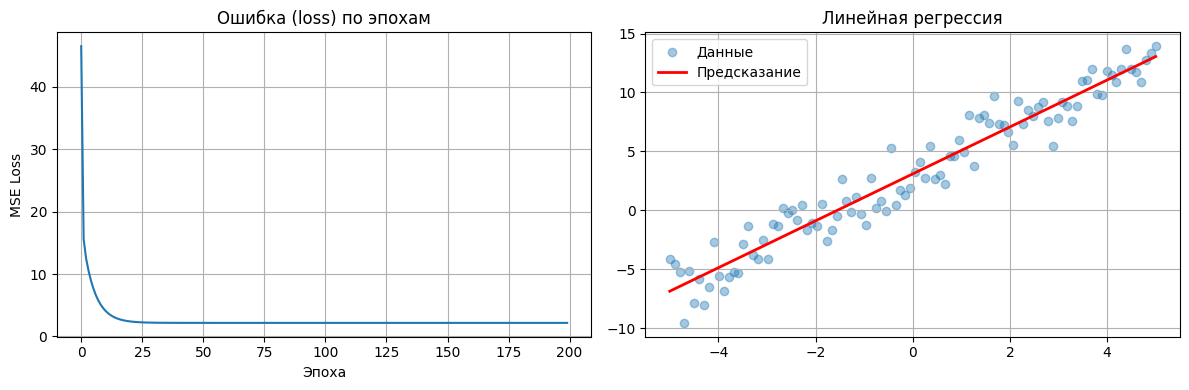

In [14]:
import torch.nn as nn

torch.manual_seed(42)

# ── Данные (y = 2x + 3 + шум) ──────────────────
x = torch.linspace(-5, 5, 100).unsqueeze(1)  # [100, 1]
y = 2 * x + 3 + torch.randn_like(x) * 1.5   # [100, 1]

# ── Модель: один линейный слой ──────────────────
model = nn.Linear(in_features=1, out_features=1)
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.05)

# ── Обучение ────────────────────────────────────
losses = []
for epoch in range(200):
    optimizer.zero_grad()          # 5. обнуляем градиенты
    y_pred = model(x)              # 1. предсказание
    loss = criterion(y_pred, y)    # 2. ошибка
    loss.backward()                # 3. градиенты
    optimizer.step()               # 4. обновление весов
    losses.append(loss.item())

w, b = model.parameters()
print(f"Обученные параметры:  w = {w.item():.3f}, b = {b.item():.3f}")
print(f"Правильные параметры: w = 2.000, b = 3.000")

# ── График ───────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(losses)
ax1.set_title("Ошибка (loss) по эпохам")
ax1.set_xlabel("Эпоха")
ax1.set_ylabel("MSE Loss")
ax1.grid(True)

with torch.no_grad():
    y_hat = model(x)
ax2.scatter(x.numpy(), y.numpy(), alpha=0.4, label="Данные")
ax2.plot(x.numpy(), y_hat.numpy(), 'r-', linewidth=2, label="Предсказание")
ax2.set_title("Линейная регрессия")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()


### 🔨 Задание 6. Настройте скорость обучения

Попробуйте разные значения `lr` (learning rate) и посмотрите, как это влияет на обучение.

Заполните словарь `experiments` результатами для трёх значений `lr`.
Финальный loss сохраните в переменную `final_loss_005` (для lr=0.05).


In [15]:
torch.manual_seed(42)

x_data = torch.linspace(-5, 5, 100).unsqueeze(1)
y_data = 2 * x_data + 3 + torch.randn_like(x_data) * 1.5

experiments = {}

for lr in [0.001, 0.05, 0.5]:
    model_exp = nn.Linear(1, 1)
    opt = torch.optim.SGD(model_exp.parameters(), lr=lr)
    crit = nn.MSELoss()
    
    history = []
    for _ in range(200):
        opt.zero_grad()
        pred = model_exp(x_data)
        loss = crit(pred, y_data)
        loss.backward()
        opt.step()
        history.append(loss.item())
    
    experiments[lr] = history
    print(f"lr={lr:.3f} → финальный loss: {history[-1]:.4f}")

# TODO: сохраните финальный loss для lr=0.05 в переменную
final_loss_005 = None  # ← experiments[0.05][-1]

# ── Проверка ──────────────────
assert final_loss_005 is not None, "❌ Сохраните финальный loss"
assert final_loss_005 < 5.0, f"❌ Loss={final_loss_005:.2f} слишком большой, что-то не так"
print(f"\n✅ Финальный loss для lr=0.05: {final_loss_005:.4f}")

# ── График ────────────────────────────────────
plt.figure(figsize=(8, 4))
for lr, hist in experiments.items():
    plt.plot(hist, label=f"lr={lr}")
plt.legend()
plt.title("Сравнение скоростей обучения")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.yscale('log')
plt.grid(True)
plt.show()


lr=0.001 → финальный loss: 9.3006
lr=0.050 → финальный loss: 2.1665
lr=0.500 → финальный loss: nan


AssertionError: ❌ Сохраните финальный loss

---
## 🏗️ Часть 8. Многослойная нейронная сеть

Используем `nn.Module` — стандартный способ создания сетей в PyTorch.


In [ ]:
import torch.nn.functional as F

class SimpleNet(nn.Module):
    def __init__(self, in_features, hidden_size, out_features):
        super().__init__()
        self.fc1 = nn.Linear(in_features, hidden_size)   # скрытый слой
        self.fc2 = nn.Linear(hidden_size, out_features)  # выходной слой
    
    def forward(self, x):
        x = F.relu(self.fc1(x))  # ReLU после первого слоя
        x = self.fc2(x)          # без активации на выходе
        return x

# Создаём сеть: 2 входа → 8 скрытых → 1 выход
net = SimpleNet(in_features=2, hidden_size=8, out_features=1)

# Считаем количество параметров
total_params = sum(p.numel() for p in net.parameters())
print("Архитектура:")
print(net)
print(f"\nВсего параметров: {total_params}")


In [ ]:
# Обучим сеть на задаче классификации (XOR)
torch.manual_seed(42)

# XOR данные: (0,0)→0, (0,1)→1, (1,0)→1, (1,1)→0
X_xor = torch.tensor([[0.,0.], [0.,1.], [1.,0.], [1.,1.]])
y_xor = torch.tensor([[0.], [1.], [1.], [0.]])

# Дублируем данные с небольшим шумом для лучшего обучения
torch.manual_seed(7)
X_big = X_xor.repeat(50, 1) + torch.randn(200, 2) * 0.2
y_big = y_xor.repeat(50, 1)

net_xor = SimpleNet(2, 8, 1)
crit = nn.MSELoss()
opt = torch.optim.Adam(net_xor.parameters(), lr=0.01)

for epoch in range(1000):
    opt.zero_grad()
    pred = torch.sigmoid(net_xor(X_big))
    loss = crit(pred, y_big)
    loss.backward()
    opt.step()

# Проверка на XOR точках
with torch.no_grad():
    preds = torch.sigmoid(net_xor(X_xor))
    print("Предсказания XOR:")
    for i, (xi, yi, pi) in enumerate(zip(X_xor, y_xor, preds)):
        correct = "✅" if abs(pi.item() - yi.item()) < 0.3 else "❌"
        print(f"  {xi.tolist()} → ожидаем {int(yi.item())}, получили {pi.item():.2f} {correct}")


### 🔨 Задание 7. Напишите свою нейросеть

Создайте класс `MyNet` с тремя линейными слоями:
- Слой 1: `in_features → 16` + ReLU
- Слой 2: `16 → 8` + ReLU
- Слой 3: `8 → out_features` (без активации)


In [16]:
class MyNet(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        # TODO: создайте три линейных слоя
        # self.fc1 = nn.Linear(in_features, 16)
        # self.fc2 = ...
        # self.fc3 = ...
        pass  # ← удалите pass после добавления слоёв
    
    def forward(self, x):
        # TODO: пропустите x через слои с ReLU после fc1 и fc2
        # x = F.relu(self.fc1(x))
        # ...
        return x  # ← замените на правильный return

# ── Проверка ──────────────────
try:
    test_net = MyNet(in_features=4, out_features=2)
    test_input = torch.randn(5, 4)
    test_output = test_net(test_input)
    
    assert test_output.shape == torch.Size([5, 2]),         f"❌ Выход должен быть [5, 2], а не {test_output.shape}"
    
    total = sum(p.numel() for p in test_net.parameters())
    # 4*16+16 + 16*8+8 + 8*2+2 = 80+136+18 = 234
    assert total > 100, f"❌ Параметров слишком мало ({total}), проверьте архитектуру"
    
    print(test_net)
    print(f"\n✅ Выход: {test_output.shape}")
    print(f"✅ Параметров: {total}")
except AttributeError as e:
    print(f"❌ Ошибка: {e}")
    print("   Убедитесь, что вы создали все три слоя (fc1, fc2, fc3)")


AssertionError: ❌ Выход должен быть [5, 2], а не torch.Size([5, 4])

---
## 💾 Часть 9. Сохранение и загрузка модели

Обученную модель нужно сохранять, чтобы использовать потом.


In [17]:
# Сохраняем веса модели
torch.save(net_xor.state_dict(), 'my_model.pt')
print("✅ Модель сохранена в 'my_model.pt'")

# Загружаем в новую модель
loaded_net = SimpleNet(2, 8, 1)
loaded_net.load_state_dict(torch.load('my_model.pt', weights_only=True))
loaded_net.eval()

print("✅ Модель загружена!")

# Проверяем, что результаты совпадают
with torch.no_grad():
    original_pred = torch.sigmoid(net_xor(X_xor))
    loaded_pred   = torch.sigmoid(loaded_net(X_xor))

diff = (original_pred - loaded_pred).abs().max().item()
print(f"\nМаксимальное расхождение предсказаний: {diff:.8f}")
print("✅ Веса загружены корректно!" if diff < 1e-6 else "❌ Что-то пошло не так")


NameError: name 'net_xor' is not defined

---
## 🏆 Итоговое задание

Соберите всё вместе! Обучите нейросеть решать задачу **классификации на спиральных данных**.


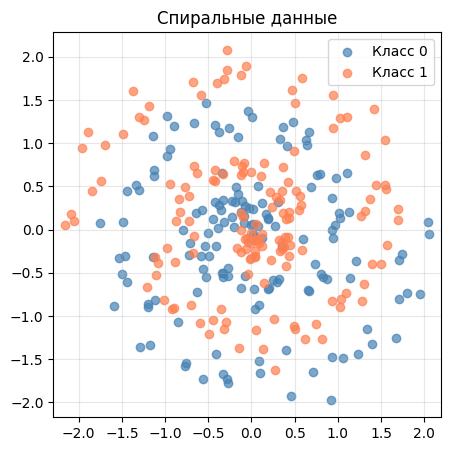

Данных: X=torch.Size([300, 2]), y=torch.Size([300])


In [20]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

# ── Генерируем спиральные данные ──────────────────
def make_spirals(n=100):
    def spiral_xy(t, delta=0):
        r = t / (2 * np.pi)
        x = r * np.cos(t + delta)
        y = r * np.sin(t + delta)
        return x, y
    
    t = np.linspace(0, 4*np.pi, n)
    x1, y1 = spiral_xy(t, 0)
    x2, y2 = spiral_xy(t, np.pi)
    
    noise = 0.15
    X = np.vstack([
        np.c_[x1 + np.random.randn(n)*noise, y1 + np.random.randn(n)*noise],
        np.c_[x2 + np.random.randn(n)*noise, y2 + np.random.randn(n)*noise]
    ])
    y = np.array([0]*n + [1]*n)
    return torch.FloatTensor(X), torch.LongTensor(y)

X, y = make_spirals(150)

plt.figure(figsize=(5, 5))
plt.scatter(X[y==0, 0], X[y==0, 1], c='steelblue', label='Класс 0', alpha=0.7)
plt.scatter(X[y==1, 0], X[y==1, 1], c='coral', label='Класс 1', alpha=0.7)
plt.legend()
plt.title("Спиральные данные")
plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.show()

print(f"Данных: X={X.shape}, y={y.shape}")


In [19]:
# TODO: создайте и обучите модель для классификации спиралей
# Подсказки:
# - Используйте MyNet(in_features=2, out_features=2) или SimpleNet(2, 16, 2)
# - Loss: nn.CrossEntropyLoss()
# - Optimizer: torch.optim.Adam(lr=0.01)
# - Эпох: 1000
# - В цикле: zero_grad → forward → loss → backward → step

# ── Ваш код здесь ──────────────────

spiral_model = None  # ← создайте модель

# ── Проверка ──────────────────
if spiral_model is not None:
    with torch.no_grad():
        logits = spiral_model(X)
        preds = logits.argmax(dim=1)
        accuracy = (preds == y).float().mean().item()
    print(f"\nТочность на всех данных: {accuracy*100:.1f}%")
    
    if accuracy > 0.85:
        print("🏆 Отлично! Точность выше 85%!")
    elif accuracy > 0.70:
        print("✅ Хорошо! Попробуйте улучшить: больше нейронов или эпох.")
    else:
        print("💡 Точность низкая. Попробуйте другую архитектуру или lr.")
else:
    print("❌ Создайте и обучите модель spiral_model")


❌ Создайте и обучите модель spiral_model


---
## 📋 Итоги

Вы изучили основы PyTorch:

| # | Тема | Ключевые функции |
|:-:|:----:|:----------------|
| 1 | Тензоры | `torch.tensor()`, `.shape`, `.ndim` |
| 2 | Создание | `zeros`, `ones`, `randn`, `linspace` |
| 3 | Операции | `+`, `*`, `@`, `.sum()`, `.mean()` |
| 4 | Форма | `.reshape()`, `.unsqueeze()`, `.squeeze()` |
| 5 | Autograd | `requires_grad=True`, `.backward()`, `.grad` |
| 6 | Обучение | `forward → loss → backward → step` |
| 7 | `nn.Module` | `__init__`, `forward`, `F.relu` |
| 8 | Сохранение | `state_dict()`, `load_state_dict()` |

### Следующий шаг 🚀
- Попробуйте добавить **Batch Normalization** (`nn.BatchNorm1d`)
- Изучите **Dropout** (`nn.Dropout`) против переобучения
- Попробуйте **2D свёртки** (`nn.Conv2d`) для изображений
